In [1]:
import sys
import os

# 모듈 자동 리로드 설정 (이 코드를 가장 먼저 실행하세요)
%load_ext autoreload
%autoreload 2

# src 폴더 경로 설정 (notebooks 폴더 상위)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# 공통 함수 모듈 임포트
from src import common_utils as utils

utils.log("✅ 환경 설정 완료")

[16:52:29] ✅ [Config] 환경 설정 완료 (OS: Darwin)
[16:52:29] ✅ 환경 설정 완료


In [2]:
# ==========================================================
# 1. 파일 경로 설정 (File Path)
# ==========================================================
# 데이터 파일 경로만 여기서 관리합니다.
FILE_PATH = "../data/10_processed/df_sha.parquet"

In [3]:
# ==========================================================
# [Cell 3] 데이터 로드 및 전처리
# ==========================================================
utils.log("🚀 데이터 로드 및 추출 시작...")

# 1. 설정 및 로드
# 전체 로드 시 None, 필요한 것만 로드 시 리스트 지정
USE_COLS = None
#USE_COLS = ['sha2_hash', 'p_mt', 'age_grp10', 'CANCEL_YN', 'TV가입회선수']

# lang='kor'/'eng' 옵션 사용 -> DataFrame 컬럼이 모두 한글로 바뀜
df = utils.load_parquet(FILE_PATH, cols=USE_COLS, lang='eng')

utils.s_view(df)
# ------------------------------------------------------
# 여기 까지 실행하고 아래 코드는 코드셀 분리해도 됨
# ------------------------------------------------------

if not df.empty:
    # ------------------------------------------------------
    # 2. 파생변수 생성 (Feature Engineering)
    # ------------------------------------------------------
    # (1) 기본 규칙 사용 (공통함수 Registry에 등록된 대로 변환)
    df = utils.create_derived_variable(df, src_col='AGE_GRP10')
    #df = utils.create_derived_variable(df, src_col='cancel_yn')
    #df = utils.create_derived_variable(df, src_col='연령대') # OK
    #df = utils.create_derived_variable(df, src_col='cancel_yn') # OK

    # (2) [옵션] 커스텀 규칙 사용 (필요 시 주석 해제 후 수정하여 사용)
    # -> 공통 규칙 무시하고 내가 원하는 대로 변환할 때 사용
    df = utils.create_derived_variable(
        df, 
        src_col='CANCEL_YN',          # 원본 컬럼명
        mapping={'해지': 1, '유지': 0},   # 내 마음대로 매핑
        new_name='DERIVED_CANCEL_YN',   # 새로운 컬럼 이름
        fillna_val=0,             # 결측치 채울 값
    )

    # 3. 데이터 추출 시나리오 (Data Extraction)
    # ------------------------------------------------------
    # [Case A] 전체 데이터 (중복제거 X)
    df = utils.get_data_set(df, 'sha2_hash', 'p_mt', dedup=False)

    # [Case B] 최신 상태 (중복제거 O, 기본값)
    #df = utils.get_data_set(df, 'SHA2_HASH', 'P_MT', target_month=None, dedup=True)

    # [Case C] 2023년 5월 데이터만 (중복제거 O)
    # df = utils.get_data_set(df, 'sha2_hash', 'p_mt', target_month=202305, dedup=True, date_op='eq')

    # [Case D] 2023년 5월까지 누적 (중복제거 O)
    # df = utils.get_data_set(df, 'sha2_hash', 'p_mt', target_month=202305, dedup=True, date_op='lte')
    
    utils.log("✅ 데이터 준비 완료")
    
    utils.s_view(df)

[16:52:32] 🚀 데이터 로드 및 추출 시작...
[16:52:45] 📂 로드 완료: 22,473,534 Rows (Selected 39 Columns)
[16:52:45] 🔢 파생변수 생성(Mapping): AGE_GRP10 -> DERIVED_AGE_GRP10



📋 [Column Dictionary] Total 39 Columns
Current Name                   | Description / Original Key
----------------------------------------------------------------------
SHA2_HASH                      | 고객ID
SVC_USE_DAYS_GRP               | 가입유지기간
MEDIA_NM_GRP                   | 방송화질등급
PROD_NM_GRP                    | 요금제등급
PROD_OLD_YN                    | 구형장비여부
PROD_ONE_PLUS_YN               | 세컨드TV여부
AGMT_KIND_NM                   | 약정유형
STB_RES_1M_YN                  | 최근1달_셋톱장애경험
SVOD_SCRB_CNT_GRP              | 월정액가입건수
PAID_CHNL_CNT_GRP              | 유료채널가입건수
SCRB_PATH_NM_GRP               | 가입경로
INHOME_RATE                    | 집체류지수
AGMT_END_SEG                   | 만료잔여기간
AGMT_END_YMD                   | 약정만료일
TOTAL_USED_DAYS                | 총사용일수
TV_SCRB                        | TV가입회선수
ANALOG_SCRB                    | 아날로그가입수
DIGITAL_SCRB                   | 디지털가입수
TOTAL_INTERNET_SCRB            | 인터넷가입수
GIGA_INTERNET_SCRB             | 기가인터넷가입수
BUNDLE_YN                 

[16:52:46] 🔢 파생변수 생성(Mapping): CANCEL_YN -> DERIVED_CANCEL_YN
[16:52:59] 📚 중복제거 미수행 (단순 정렬): 22,473,534 행
[16:53:00] ✅ 데이터 준비 완료



📋 [Column Dictionary] Total 41 Columns
Current Name                   | Description / Original Key
----------------------------------------------------------------------
SHA2_HASH                      | 고객ID
SVC_USE_DAYS_GRP               | 가입유지기간
MEDIA_NM_GRP                   | 방송화질등급
PROD_NM_GRP                    | 요금제등급
PROD_OLD_YN                    | 구형장비여부
PROD_ONE_PLUS_YN               | 세컨드TV여부
AGMT_KIND_NM                   | 약정유형
STB_RES_1M_YN                  | 최근1달_셋톱장애경험
SVOD_SCRB_CNT_GRP              | 월정액가입건수
PAID_CHNL_CNT_GRP              | 유료채널가입건수
SCRB_PATH_NM_GRP               | 가입경로
INHOME_RATE                    | 집체류지수
AGMT_END_SEG                   | 만료잔여기간
AGMT_END_YMD                   | 약정만료일
TOTAL_USED_DAYS                | 총사용일수
TV_SCRB                        | TV가입회선수
ANALOG_SCRB                    | 아날로그가입수
DIGITAL_SCRB                   | 디지털가입수
TOTAL_INTERNET_SCRB            | 인터넷가입수
GIGA_INTERNET_SCRB             | 기가인터넷가입수
BUNDLE_YN                 

In [4]:
# ==========================================================
# [Cell 4] 데이터 구조 및 품질 확인 (Info View)
# ==========================================================
if 'df' in locals() and not df.empty:
    utils.i_view(df)
else:
    print("⚠️ df 변수가 없습니다. Cell 3를 먼저 실행하세요.")


📊 [Structure] Shape: (22473534, 41)


,SHA2_HASH,SVC_USE_DAYS_GRP,MEDIA_NM_GRP,PROD_NM_GRP,PROD_OLD_YN,PROD_ONE_PLUS_YN,AGMT_KIND_NM,STB_RES_1M_YN,SVOD_SCRB_CNT_GRP,PAID_CHNL_CNT_GRP,...,CH_25_RATIO_MONTH1,CH_25_RATIO_MEAN_3MM,CH_FAV_RNK1,KIDS_USE_PV_MONTH1,NFX_USE_YN,YTB_USE_YN,P_MT,CANCEL_YN,DERIVED_AGE_GRP10,DERIVED_CANCEL_YN
0,0000113b86db7c509bbe74d609529031b03b7c033dbdfb...,24개월~ 36개월미만,HD,이코노미,N,Y,재약정,N,0건,0건,...,3.85,3.85,KBS2,0.0,N,N,202312,유지,6,0
1,0000113b86db7c509bbe74d609529031b03b7c033dbdfb...,24개월~ 36개월미만,HD,이코노미,N,Y,재약정,N,0건,0건,...,4.72,4.72,기타,0.0,N,N,202311,유지,6,0
2,0000113b86db7c509bbe74d609529031b03b7c033dbdfb...,24개월~ 36개월미만,HD,이코노미,N,Y,재약정,N,0건,0건,...,8.67,8.67,기타,0.0,N,N,202310,유지,6,0
3,0000113b86db7c509bbe74d609529031b03b7c033dbdfb...,24개월~ 36개월미만,HD,이코노미,N,Y,재약정,N,0건,0건,...,6.46,6.46,기타,0.0,N,N,202309,유지,6,0
4,0000113b86db7c509bbe74d609529031b03b7c033dbdfb...,24개월~ 36개월미만,HD,이코노미,N,Y,재약정,N,0건,0건,...,0.03,0.03,JTBC,0.0,N,N,202308,유지,6,0



🔍 [Quality Summary]


,Dtype,Null_Count,N_Unique
SHA2_HASH,object,0,2175327
SVC_USE_DAYS_GRP,object,0,5
MEDIA_NM_GRP,object,0,3
PROD_NM_GRP,object,0,6
PROD_OLD_YN,object,0,2
PROD_ONE_PLUS_YN,object,0,2
AGMT_KIND_NM,object,0,7
STB_RES_1M_YN,object,33,2
SVOD_SCRB_CNT_GRP,object,0,5
PAID_CHNL_CNT_GRP,object,0,5


In [6]:
COL_KR_MAP = {
    # 고객 식별 / 기본
    "sha2_hash": "고객ID",

    # 계약 / 약정
    "SVC_USE_DAYS_GRP": "가입유지기간",
    "AGMT_KIND_NM": "약정유형",
    "AGMT_END_SEG": "만료잔여기간",
    "AGMT_END_YMD": "약정만료일(잔여일수)",

    # 상품 / 장비
    "MEDIA_NM_GRP": "방송화질등급",
    "PROD_NM_GRP": "요금제등급",
    "PROD_OLD_YN": "구형장비여부",
    "PROD_ONE_PLUS_YN": "세컨드TV여부",

    # 가입 구성
    "TV_SCRB": "TV가입회선수",
    "ANALOG_SCRB": "아날로그가입수",
    "DIGITAL_SCRB": "디지털가입수",
    "TOTAL_INTERNET_SCRB": "인터넷가입수",
    "GIGA_INTERNET_SCRB": "기가인터넷가입수",

    # 결합
    "BUNDLE_YN": "결합상품여부",
    "DIGITAL_GIGA_YN": "디지털_기가결합",
    "DIGITAL_ALOG_YN": "디지털_아날로그결합",
    "TV_I_CNT": "TV_인터넷_결합수",

    # 시청 행태
    "CH_LAST_DAYS_BF_GRP": "마지막시청_경과일",
    "CH_HH_AVG_MONTH1": "일평균시청시간",
    "CH_25_RATIO_MONTH1": "25번채널시청비중",
    "CH_25_RATIO_MEAN_3MM": "최근3달_25번비중",
    "CH_FAV_RNK1": "선호채널_1위",
    "KIDS_USE_PV_MONTH1": "키즈시청건수",

    # OTT
    "NFX_USE_YN": "넷플릭스사용여부",
    "YTB_USE_YN": "유튜브사용여부",

    # 고객 특성
    "AGE_GRP10": "연령대",
    "INHOME_RATE": "댁내체류지수",

    # VOC / 장애
    "STB_RES_1M_YN": "최근1달_셋톱장애경험",
    "VOC_TOTAL_MONTH1_YN": "최근1달_민원접수",
    "VOC_STOP_CANCEL_MONTH1_YN": "최근1달_해지방어",

    # 마케팅 수신
    "EMAIL_RECV_CLS_NM": "이메일수신동의",
    "SMS_SEND_CLS_NM": "SMS수신동의",

    # 기타
    "SCRB_PATH_NM_GRP": "가입경로",
    "SVOD_SCRB_CNT_GRP": "월정액가입건수",
    "PAID_CHNL_CNT_GRP": "유료채널가입건수",
    "TOTAL_USED_DAYS": "총사용일수",

    # 시간 / 라벨
    "p_mt": "기준년월",
    "cancel_yn": "해지여부",
    "DERIVED_CANCEL_YN": "해지여부(이진)"
}


In [10]:
from dataclasses import dataclass, field
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


@dataclass
class XGBWalkForwardExperiment:
    df: pd.DataFrame
    target_col: str = "DERIVED_CANCEL_YN"
    month_col: str = "P_MT"

    drop_cols: List[str] = field(default_factory=lambda: [
        "SHA2_HASH", "CANCEL_YN", "P_MT", "derived_cancel_yn"
    ])

    top_pct: float = 0.05
    random_state: int = 42

    xgb_params: Dict = field(default_factory=lambda: dict(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        n_jobs=-1,
    ))

    # ----------------------------
    def _build_Xy(self, df_part: pd.DataFrame):
        drop = [c for c in self.drop_cols if c in df_part.columns]
        X = df_part.drop(columns=drop + [self.target_col], errors="ignore")
        y = df_part[self.target_col].astype(int)
        return X, y

    # ----------------------------
    def _fit_predict(self, train_df: pd.DataFrame, test_df: pd.DataFrame):
        X_tr, y_tr = self._build_Xy(train_df)
        X_te, y_te = self._build_Xy(test_df)

        # 범주형/수치형 분리 (train 기준)
        cat_cols = X_tr.select_dtypes(include=["object"]).columns.tolist()
        num_cols = [c for c in X_tr.columns if c not in cat_cols]

        preprocess = ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", "passthrough", num_cols)
        ])

        pos = int((y_tr == 1).sum())
        neg = int((y_tr == 0).sum())
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0

        model = XGBClassifier(
            **self.xgb_params,
            scale_pos_weight=scale_pos_weight,
            random_state=self.random_state
        )

        clf = Pipeline([
            ("prep", preprocess),
            ("model", model)
        ])

        clf.fit(X_tr, y_tr)

        proba = clf.predict_proba(X_te)[:, 1]

        # AUC는 test에 클래스가 2개 있어야 계산 가능
        auc = roc_auc_score(y_te, proba) if len(np.unique(y_te)) > 1 else np.nan

        # Top% Lift
        cut = np.quantile(proba, 1 - self.top_pct)
        top_mask = proba >= cut

        base_rate = float(y_te.mean())
        top_rate = float(y_te[top_mask].mean()) if int(top_mask.sum()) > 0 else np.nan
        lift = float(top_rate / base_rate) if base_rate > 0 else np.nan

        return dict(
            auc=float(auc) if auc == auc else np.nan,
            base_rate=base_rate,
            top_rate=top_rate,
            lift=lift,
            n_train=len(y_tr),
            n_test=len(y_te),
            n_top=int(top_mask.sum()),
            n_features=X_tr.shape[1],
        )

    # ----------------------------
    def run_expanding_walkforward(
        self,
        train_start_month: int,
        test_months: Optional[List[int]] = None,
    ):
        df_all = self.df.copy()
        df_all[self.month_col] = df_all[self.month_col].astype(int)

        months = sorted(df_all[self.month_col].unique())

        # test_months 안 주면: train_start_month 다음달부터 끝까지 자동
        if test_months is None:
            months_after_start = [m for m in months if m >= train_start_month]
            test_months = months_after_start[1:]  # start 다음 달부터

        rows = []

        for tm in test_months:
            tm = int(tm)

            train_df = df_all[(df_all[self.month_col] >= int(train_start_month)) & (df_all[self.month_col] < tm)]
            test_df  = df_all[df_all[self.month_col] == tm]

            if train_df.empty or test_df.empty:
                continue

            res = self._fit_predict(train_df, test_df)

            rows.append({
                "test_month": tm,
                "train_month_from": int(train_start_month),
                "train_month_to": int(max(train_df[self.month_col])),
                **res
            })

        return pd.DataFrame(rows)


In [11]:
wf = XGBWalkForwardExperiment(df=df)

# train_start_month부터 누적학습, 다음 달부터 자동으로 쭉 테스트
wf_df = wf.run_expanding_walkforward(train_start_month=202302)

display(wf_df)


,test_month,train_month_from,train_month_to,auc,base_rate,top_rate,lift,n_train,n_test,n_top,n_features
0,202303,202302,202302,0.722890,0.082776,0.340169,4.109506,2049606,2048214,102411,37
1,202304,202302,202303,0.723477,0.076990,0.320774,4.166428,4097820,2046732,102337,37
2,202305,202302,202304,0.726462,0.071388,0.307187,4.303070,6144552,2046691,102335,37
3,202306,202302,202305,0.727108,0.064969,0.283727,4.367122,8191243,2045398,102271,37
4,202307,202302,202306,0.729152,0.058720,0.263526,4.487818,10236641,2043879,102195,37
5,202308,202302,202307,0.732342,0.052243,0.237112,4.538617,12280520,2041468,102074,37
6,202309,202302,202308,0.733877,0.046110,0.210654,4.568483,14321988,2040958,102049,37
7,202310,202302,202309,0.738469,0.039779,0.184710,4.643388,16362946,2039944,101998,37
8,202311,202302,202310,0.738220,0.032639,0.144076,4.414174,18402890,2037109,101856,37
9,202312,202302,202311,0.738935,0.026033,0.108304,4.160171,20439999,2033535,101677,37


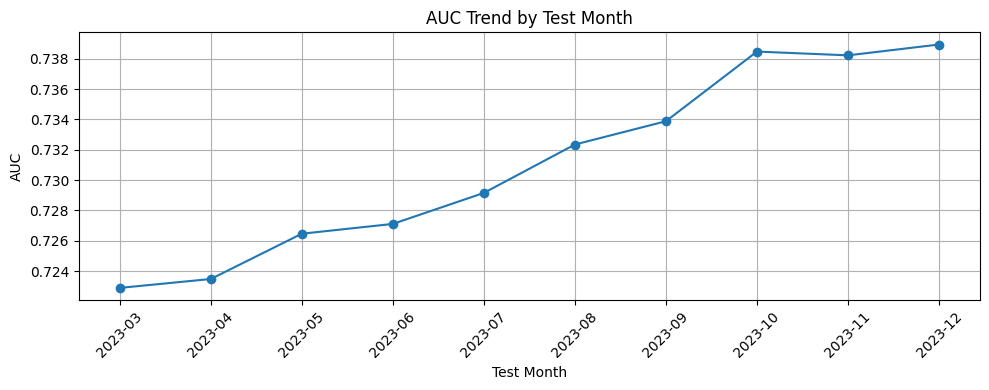

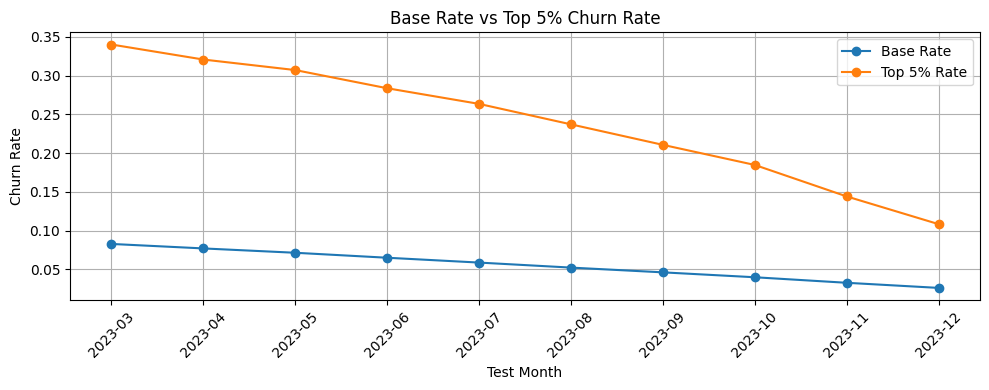

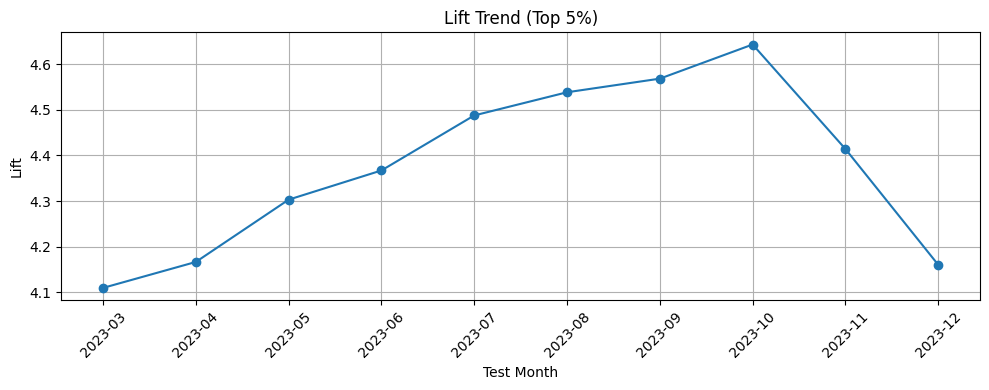

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) 결과표 입력 (복붙용)
# =========================
df = pd.DataFrame([
    {"test_month":202303, "train_month_from":202302, "train_month_to":202302, "auc":0.722890, "base_rate":0.082776, "top_rate":0.340169, "lift":4.109506, "n_train":2049606, "n_test":2048214, "n_top":102411, "n_features":37},
    {"test_month":202304, "train_month_from":202302, "train_month_to":202303, "auc":0.723477, "base_rate":0.076990, "top_rate":0.320774, "lift":4.166428, "n_train":4097820, "n_test":2046732, "n_top":102337, "n_features":37},
    {"test_month":202305, "train_month_from":202302, "train_month_to":202304, "auc":0.726462, "base_rate":0.071388, "top_rate":0.307187, "lift":4.303070, "n_train":6144552, "n_test":2046691, "n_top":102335, "n_features":37},
    {"test_month":202306, "train_month_from":202302, "train_month_to":202305, "auc":0.727108, "base_rate":0.064969, "top_rate":0.283727, "lift":4.367122, "n_train":8191243, "n_test":2045398, "n_top":102271, "n_features":37},
    {"test_month":202307, "train_month_from":202302, "train_month_to":202306, "auc":0.729152, "base_rate":0.058720, "top_rate":0.263526, "lift":4.487818, "n_train":10236641, "n_test":2043879, "n_top":102195, "n_features":37},
    {"test_month":202308, "train_month_from":202302, "train_month_to":202307, "auc":0.732342, "base_rate":0.052243, "top_rate":0.237112, "lift":4.538617, "n_train":12280520, "n_test":2041468, "n_top":102074, "n_features":37},
    {"test_month":202309, "train_month_from":202302, "train_month_to":202308, "auc":0.733877, "base_rate":0.046110, "top_rate":0.210654, "lift":4.568483, "n_train":14321988, "n_test":2040958, "n_top":102049, "n_features":37},
    {"test_month":202310, "train_month_from":202302, "train_month_to":202309, "auc":0.738469, "base_rate":0.039779, "top_rate":0.184710, "lift":4.643388, "n_train":16362946, "n_test":2039944, "n_top":101998, "n_features":37},
    {"test_month":202311, "train_month_from":202302, "train_month_to":202310, "auc":0.738220, "base_rate":0.032639, "top_rate":0.144076, "lift":4.414174, "n_train":18402890, "n_test":2037109, "n_top":101856, "n_features":37},
    {"test_month":202312, "train_month_from":202302, "train_month_to":202311, "auc":0.738935, "base_rate":0.026033, "top_rate":0.108304, "lift":4.160171, "n_train":20439999, "n_test":2033535, "n_top":101677, "n_features":37},
])

# x축을 보기 좋게 문자열로(202303 -> "2023-03")
df["test_month_str"] = df["test_month"].astype(str).str[:4] + "-" + df["test_month"].astype(str).str[4:]

# =========================
# 2) 그래프 1: AUC 추이
# =========================
plt.figure(figsize=(10,4))
plt.plot(df["test_month_str"], df["auc"], marker="o")
plt.title("AUC Trend by Test Month")
plt.xlabel("Test Month")
plt.ylabel("AUC")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 3) 그래프 2: Base vs Top5% 해지율
# =========================
plt.figure(figsize=(10,4))
plt.plot(df["test_month_str"], df["base_rate"], marker="o", label="Base Rate")
plt.plot(df["test_month_str"], df["top_rate"], marker="o", label="Top 5% Rate")
plt.title("Base Rate vs Top 5% Churn Rate")
plt.xlabel("Test Month")
plt.ylabel("Churn Rate")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 4) 그래프 3: Lift 추이
# =========================
plt.figure(figsize=(10,4))
plt.plot(df["test_month_str"], df["lift"], marker="o")
plt.title("Lift Trend (Top 5%)")
plt.xlabel("Test Month")
plt.ylabel("Lift")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


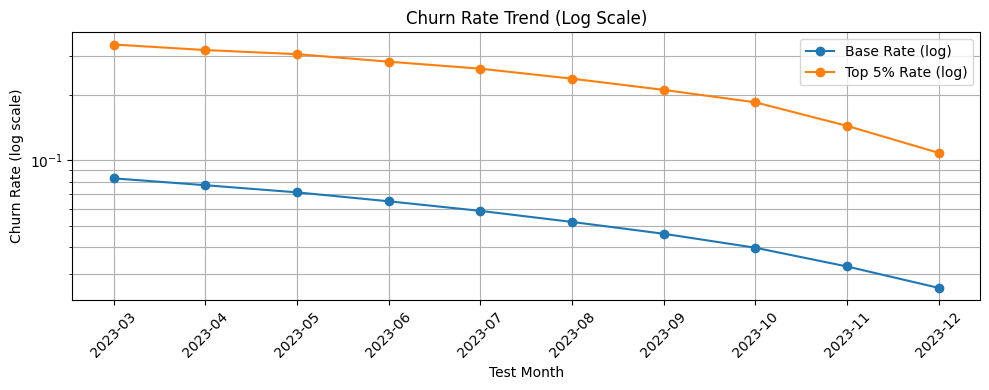

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.semilogy(df["test_month_str"], df["base_rate"], marker="o", label="Base Rate (log)")
plt.semilogy(df["test_month_str"], df["top_rate"], marker="o", label="Top 5% Rate (log)")

plt.title("Churn Rate Trend (Log Scale)")
plt.xlabel("Test Month")
plt.ylabel("Churn Rate (log scale)")
plt.legend()
plt.grid(True, which="both")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
#최종 월 결과 확인
last_row = wf_df.sort_values("test_month").tail(1)
display(last_row)
                                                                  

,test_month,train_month_from,train_month_to,auc,base_rate,top_rate,lift,n_train,n_test,n_top,n_features
9,202312,202302,202311,0.738935,0.026033,0.108304,4.160171,20439999,2033535,101677,37
